<a href="https://colab.research.google.com/github/kyathamkarthik/datacenter-power-consumption-prediction/blob/main/notebooks/power_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/kyathamkarthik/datacenter-power-consumption-prediction/refs/heads/main/powerconsumption.csv"

df = pd.read_csv(url)

df.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Datetime                52416 non-null  object 
 1   Temperature             52416 non-null  float64
 2   Humidity                52416 non-null  float64
 3   WindSpeed               52416 non-null  float64
 4   GeneralDiffuseFlows     52416 non-null  float64
 5   DiffuseFlows            52416 non-null  float64
 6   PowerConsumption_Zone1  52416 non-null  float64
 7   PowerConsumption_Zone2  52416 non-null  float64
 8   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


In [4]:
# Check Dataset Statistics

df.describe()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360




1.   Load dataset
2.   Convert time column
3.   Prepare dataset for time-series analysis
4.   Preview data
5.   Analyze dataset structure
6.   Generate statistics
7.   List item
*   This stage is called EDA (Exploratory Data Analysis).

      **Why This Is Important For Your Project**
       
* Before building any ML model, data scientists must:


1.   Understand the data
2.   Check data quality
3.   Analyze patterns









In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset from GitHub
url = "https://raw.githubusercontent.com/kyathamkarthik/datacenter-power-consumption-prediction/refs/heads/main/powerconsumption.csv"
df = pd.read_csv(url)

# Convert Datetime column to datetime format
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Set Datetime as index
df = df.set_index('Datetime')

# Show first rows
print("Dataset preview:")
print(df.head())

# Check dataset structure
print("\nDataset information:")
print(df.info())

# Summary statistics
print("\nDataset statistics:")
print(df.describe())

Dataset preview:
                     Temperature  Humidity  WindSpeed  GeneralDiffuseFlows  \
Datetime                                                                     
2017-01-01 00:00:00        6.559      73.8      0.083                0.051   
2017-01-01 00:10:00        6.414      74.5      0.083                0.070   
2017-01-01 00:20:00        6.313      74.5      0.080                0.062   
2017-01-01 00:30:00        6.121      75.0      0.083                0.091   
2017-01-01 00:40:00        5.921      75.7      0.081                0.048   

                     DiffuseFlows  PowerConsumption_Zone1  \
Datetime                                                    
2017-01-01 00:00:00         0.119             34055.69620   
2017-01-01 00:10:00         0.085             29814.68354   
2017-01-01 00:20:00         0.100             29128.10127   
2017-01-01 00:30:00         0.096             28228.86076   
2017-01-01 00:40:00         0.085             27335.69620   

        

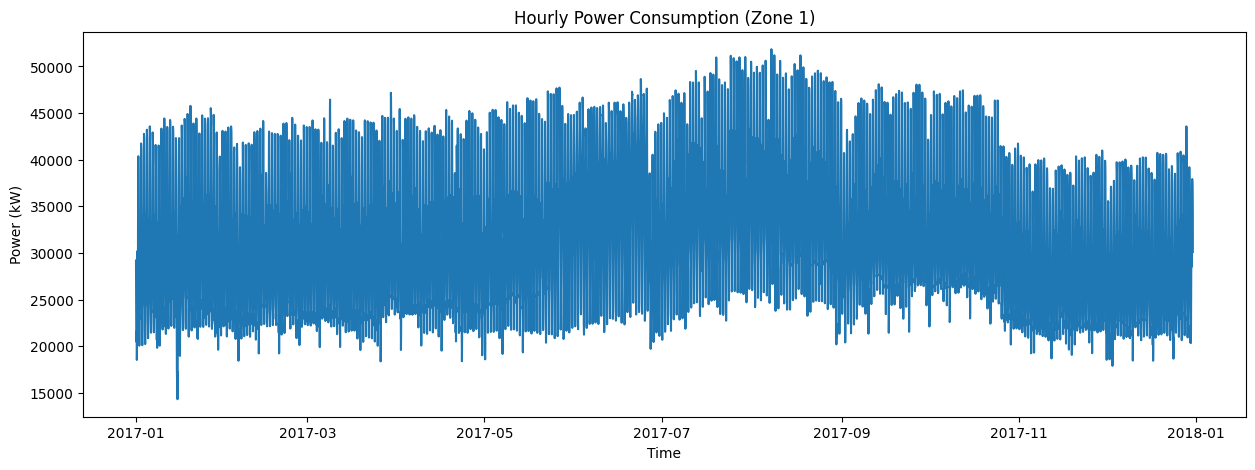

In [9]:
# Visualize Power Consumption Trend
# This graph shows when power usage peaks.

import matplotlib.pyplot as plt

df_hourly = df['PowerConsumption_Zone1'].resample('h').mean()

plt.figure(figsize=(15,5))
plt.plot(df_hourly)
plt.title("Hourly Power Consumption (Zone 1)")
plt.ylabel("Power (kW)")
plt.xlabel("Time")
plt.show()

**Correlation Heatmap**
* This shows how variables influence power usage

**Which features affect power:**
* Temperature
* Humidity
* Wind Speed
* Time


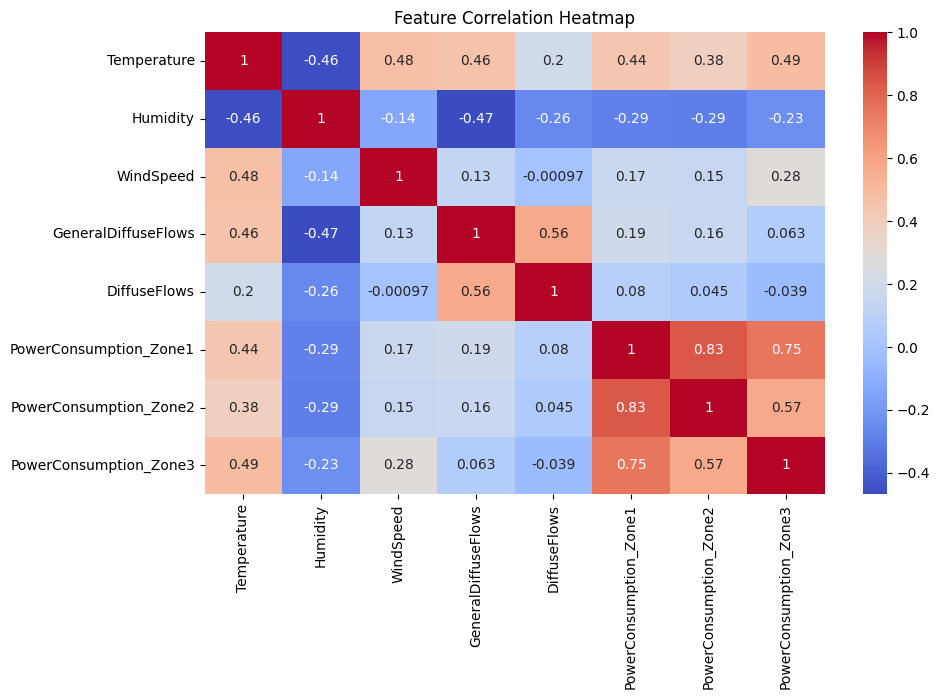

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

**Feature Engineering (VERY IMPORTANT)**
* Machine learning models learn better when we create **time features**

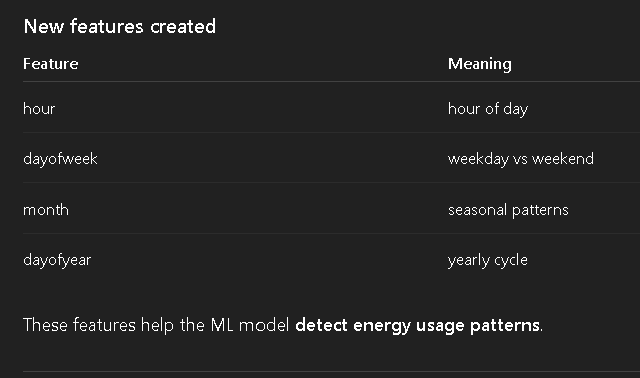

In [11]:
def create_features(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['dayofyear'] = df.index.dayofyear
    return df

df = create_features(df)

df.head()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,hour,dayofweek,month,dayofyear
Datetime,,,,,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,0,6,1,1
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,0,6,1,1
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,0,6,1,1
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,0,6,1,1
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,0,6,1,1


**Define Features for ML Model**

* Now your dataset is ready for machine learning training.(after defining features)

In [12]:
FEATURES = ['hour','dayofweek','month','dayofyear','Temperature','Humidity']
TARGET = 'PowerConsumption_Zone1'

X = df[FEATURES]
y = df[TARGET]

print(X.head())

                     hour  dayofweek  month  dayofyear  Temperature  Humidity
Datetime                                                                     
2017-01-01 00:00:00     0          6      1          1        6.559      73.8
2017-01-01 00:10:00     0          6      1          1        6.414      74.5
2017-01-01 00:20:00     0          6      1          1        6.313      74.5
2017-01-01 00:30:00     0          6      1          1        6.121      75.0
2017-01-01 00:40:00     0          6      1          1        5.921      75.7
